In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.logger import setup_logging, get_logger
from src.db import load_missions_full
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

setup_logging()
log = get_logger(__name__)

df = load_missions_full()

18:39:16  INFO      Logging initialised — file: F:\projects\space_mission_analysis\notebooks\logs\space_missions.log
18:39:16  INFO      Database engine initialised — localhost:5433/space_missions
18:39:16  INFO      load_missions_full → 10,500 rows


In [2]:
sns.set_theme(
    style="darkgrid",
    context="talk",
    palette="viridis"
)

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False
})

In [3]:
print(f"Total missions:      {len(df):,}")
print(f"Unique agencies:     {df['agency_name'].nunique()}")
print(f"Unique countries:    {df['country_region'].nunique()}")
print(f"Year range:          {df['launch_year'].min()} — {df['launch_year'].max()}")
print(f"Crewed missions:     {(df['crew_type']=='Crewed').sum():,}")
print(f"Uncrewed missions:   {(df['crew_type']=='Uncrewed').sum():,}")
print(f"\nStatus breakdown:")
print(df["status"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

Total missions:      10,500
Unique agencies:     27
Unique countries:    10
Year range:          1957 — 2035
Crewed missions:     2,637
Uncrewed missions:   7,863

Status breakdown:
status
Success            41.09%
Ongoing            29.94%
Upcoming           14.86%
Failed              8.66%
Partial Success     5.46%
Name: proportion, dtype: object


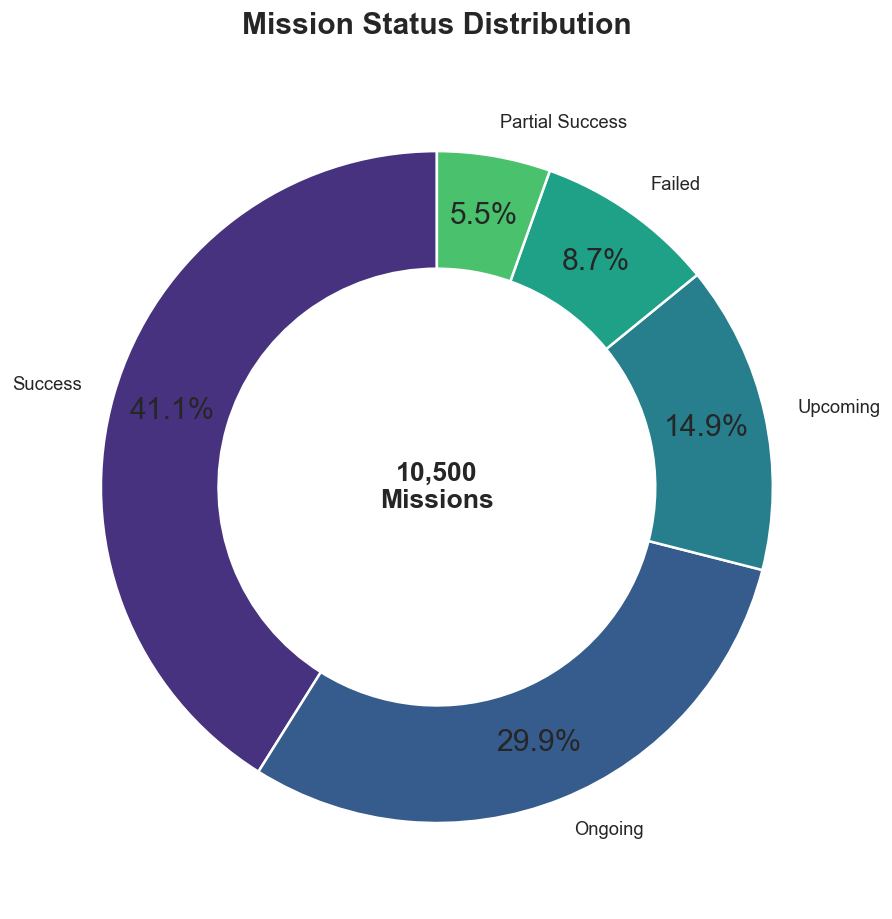

In [4]:
status_counts = df["status"].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.35)
)

# Center circle text
ax.text(
    0, 0,
    f"{status_counts.sum():,}\nMissions",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

ax.set_title("Mission Status Distribution", pad=20)

plt.tight_layout()
plt.show()

In [47]:
agency_summary = df.groupby("agency_name").agg(
    total_missions=("mission_id", "count"),
    successful_missions=("status", lambda x: (x == "Success").sum()),
    failed_missions=("status", lambda x: (x == "Failed").sum()),
    upcoming_missions=("status", lambda x: (x == "Upcoming").sum()),
    ongoing_missions=("status", lambda x: (x == "Ongoing").sum()),
    partially_successful_missions=("status", lambda x: (x == "Partially Successful").sum()),
    avg_cost_million=("cost_usd_million", lambda x: round(x.mean(), 2)),
    total_cost_million=("cost_usd_million", "sum"),
    avg_duration_days=("duration_days", lambda x: round(x.mean(), 2)),
    agency_type=("agency_type", lambda x: x.mode()[0] if not x.mode().empty else "Unknown"),
    crewed_missions=("crew_type", lambda x: (x == "Crewed").sum()),).reset_index()

agency_summary["success_rate"] = (agency_summary["successful_missions"] / agency_summary["total_missions"] * 100).round(2)



agency_summary = agency_summary[agency_summary["total_missions"] > 5]

agency_summary["cost_per_success"] = (
    pd.to_numeric(agency_summary["total_cost_million"]) / agency_summary["successful_missions"]).round(2)

agency_summary["success_rate"] = agency_summary["success_rate"].apply(lambda x: f"{x:.2f}%")

agency_summary.reset_index(drop=True, inplace=True)
agency_summary

,agency_name,total_missions,successful_missions,failed_missions,upcoming_missions,ongoing_missions,partially_successful_missions,avg_cost_million,total_cost_million,avg_duration_days,agency_type,crewed_missions,success_rate,cost_per_success
0,ASI,816,325,73,116,255,0,7521.00,6137139.30,2549.44,Government,207,39.83%,18883.51
1,Blue Origin,856,364,64,118,262,0,7397.88,6332585.30,2505.43,Private,223,42.52%,17397.21
2,CNES,812,310,74,125,255,0,7434.69,6036969.50,2512.63,Government,206,38.18%,19474.10
3,CNSA,904,376,63,152,269,0,7281.40,6582385.50,2483.38,Government,206,41.59%,17506.34
4,CSA,777,315,64,125,236,0,7480.57,5812402.30,2570.99,Government,194,40.54%,18452.07
5,DLR,849,343,82,133,244,0,7367.65,6255138.80,2603.51,Government,229,40.40%,18236.56
6,ESA,891,357,80,143,272,0,7571.05,6745809.60,2503.36,Government,242,40.07%,18895.83
7,ISRO,840,354,88,118,231,0,7514.46,6312146.80,2464.44,Government,214,42.14%,17830.92
8,JAXA,890,372,80,142,248,0,7218.55,6424511.10,2612.79,Government,230,41.80%,17270.19
9,NASA,973,392,86,135,299,0,7153.29,6960146.90,2596.59,Government,220,40.29%,17755.48
